Importar librerías

In [1]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Dataset de ejemplo
from sklearn.datasets import fetch_california_housing

# Separación de datos
from sklearn.model_selection import train_test_split

# Modelo de regresión lineal
from sklearn.linear_model import LinearRegression

# Métricas de evaluación
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Cargar Dataset

In [2]:
# ==========================================
# CARGAR DATASET
# ==========================================

# Cargar el dataset California Housing
housing = fetch_california_housing(as_frame=True)

# Convertir a DataFrame
df = housing.frame

# Mostrar primeras filas
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Explorar datos

In [3]:
# ==========================================
# EXPLORACIÓN INICIAL
# ==========================================

# Tamaño del dataset
print("Filas y columnas:")
print(df.shape)

# Tipos de datos
print("\nInformación general:")
df.info()

# Estadísticas descriptivas
print("\nResumen estadístico:")
df.describe()

Filas y columnas:
(20640, 9)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Resumen estadístico:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Identificar variable objetivo

In [4]:
# ==========================================
# VARIABLE OBJETIVO
# ==========================================

# Queremos predecir el valor medio de una vivienda
# La variable objetivo será "MedHouseVal"

print(df.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


Separar X & Y

In [5]:
# ==========================================
# SEPARAR VARIABLES
# ==========================================

# X contiene las variables predictoras
X = df.drop("MedHouseVal", axis=1)

# y contiene la variable objetivo
y = df["MedHouseVal"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (20640, 8)
Dimensiones de y: (20640,)


Dividir entrenamiento y prueba

In [6]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

# 80% entrenamiento
# 20% prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos entrenamiento:", X_train.shape)
print("Datos prueba:", X_test.shape)

Datos entrenamiento: (16512, 8)
Datos prueba: (4128, 8)


Crear modelo

In [7]:
# ==========================================
# CREAR MODELO
# ==========================================

# Instanciamos el modelo
model = LinearRegression()

print(model)

LinearRegression()


Entrenar modelo

In [8]:
# ==========================================
# ENTRENAMIENTO
# ==========================================

# El modelo aprende patrones
# entre las variables X y la variable objetivo y

model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


Realizar predicciones

In [9]:
# ==========================================
# PREDICCIONES
# ==========================================

# Generamos predicciones sobre los datos
# que el modelo nunca ha visto

y_pred = model.predict(X_test)

# Primeras predicciones
print(y_pred[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


Comparar resultados

In [10]:
# ==========================================
# COMPARAR REALES VS PREDICCIONES
# ==========================================

comparacion = pd.DataFrame({
    "Valor Real": y_test.values[:10],
    "Prediccion": y_pred[:10]
})

comparacion

,Valor Real,Prediccion
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


Evaluar modelo

In [11]:
# ==========================================
# EVALUACIÓN
# ==========================================

# Error absoluto medio
mae = mean_absolute_error(y_test, y_pred)

# Error cuadrático medio
mse = mean_squared_error(y_test, y_pred)

# Coeficiente de determinación
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 0.5332
MSE: 0.5559
R²: 0.5758


Interpretar métricas

In [12]:
# ==========================================
# INTERPRETACIÓN
# ==========================================

print("Interpretación:")

print(f"""
MAE = {mae:.4f}

En promedio el modelo se equivoca
{mae:.4f} unidades.
""")

print(f"""
R² = {r2:.4f}

El modelo explica aproximadamente
{r2*100:.2f}% de la variabilidad.
""")

Interpretación:

MAE = 0.5332

En promedio el modelo se equivoca
0.5332 unidades.


R² = 0.5758

El modelo explica aproximadamente
57.58% de la variabilidad.



Visualizar predicciones

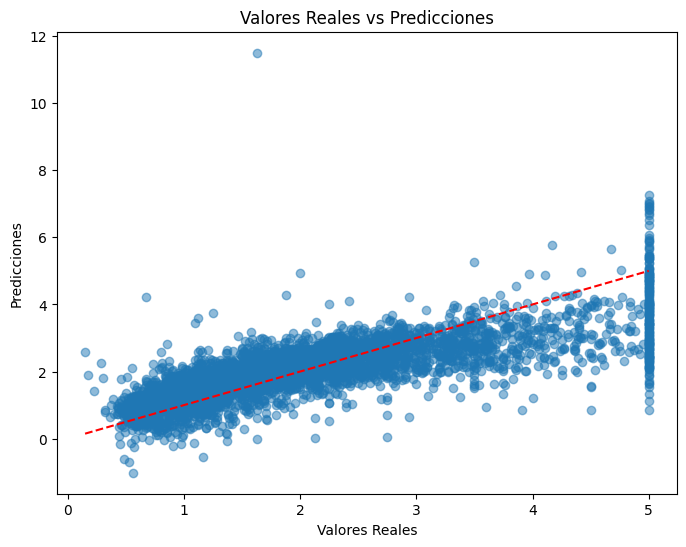

In [18]:
# ==========================================
# GRÁFICO REAL VS PREDICHO
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones")

plt.show()

Analizar coeficientes

In [14]:
# ==========================================
# COEFICIENTES DEL MODELO
# ==========================================

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": model.coef_
})

coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

,Variable,Coeficiente
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708
